# Exploratory Data Analysis
## Last-Mile Delivery Operations

Structured EDA answering the 9 business questions defined in
`reports/01_business_understanding.md`. Runs on the **cleaned** dataset
from `data/processed/`.

Per the BUSINESS UNDERSTANDING & REQUIREMENTS scope decision: there is no date/timestamp column in this
dataset, so calendar trend analysis (daily/weekly/monthly/seasonal) is
not performed. Instead, the "segment distribution" angle is covered via
`delivery_mode` and `package_type`, which behave as comparable
operational segments.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from config.config import PROCESSED_DATA_FILE, FIGURES_DIR
from src.visualization.charts import (
    plot_status_distribution, plot_segment_status, plot_numeric_status,
    plot_distance_vs_metric, plot_rating_by_status,
    plot_correlation_heatmap
)

sns.set_style("whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_FILE)
df.shape

(25000, 16)

## 1. Delivery Performance

Answers Business Question 1: overall on-time / delayed / failed rate.

delivery_status
delivered    73.32
delayed      21.36
failed        5.31
Name: proportion, dtype: float64


e:\Python projects\last-mile-delivery-analysis\src\visualization\charts.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")


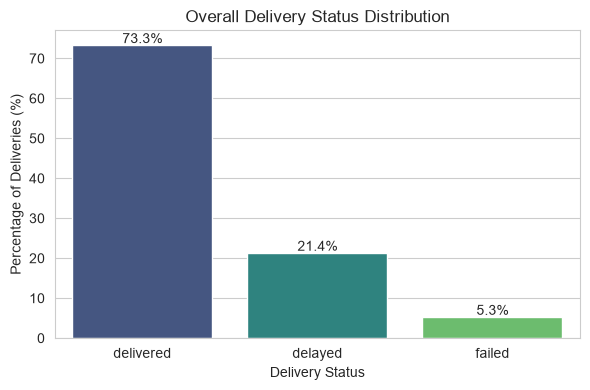

In [2]:
status_rate = df['delivery_status'].value_counts(normalize=True).mul(100).round(2)
print(status_rate)

fig = plot_status_distribution(df)
fig.savefig(FIGURES_DIR / "01_overall_delivery_status_distribution.png", dpi=150)
plt.show()

**Finding:** 73.3% of deliveries are on time (`delivered`), 21.4% are
`delayed`, and 5.3% are `failed`. Roughly 1 in 4 deliveries does not meet
the on-time standard, and 1 in 19 fails outright — both are material
operational problems worth investigating by segment below.

## 2. Geographic / Regional Performance

Answers Business Question 2.

delivery_status  delayed  delivered  failed
region                                     
central            21.60      72.75    5.65
east               20.82      74.20    4.98
north              21.80      73.43    4.77
south              21.28      73.22    5.51
west               21.32      73.05    5.63


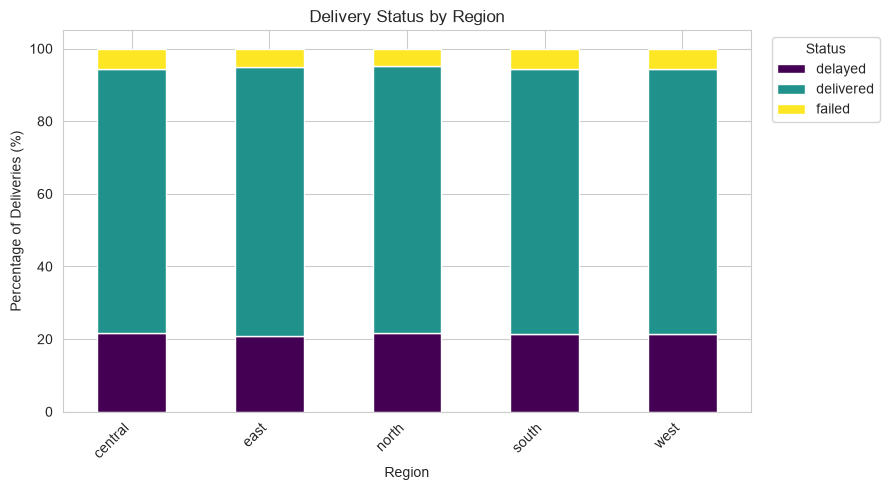

In [3]:
region_status = pd.crosstab(df['region'], df['delivery_status'], normalize='index').mul(100).round(2)
print(region_status)

fig = plot_segment_status(df, 'region')
fig.savefig(FIGURES_DIR / "02_delivery_status_by_region.png", dpi=150)
plt.show()

**Finding:** Delay and failure rates are essentially flat across all 5
regions (delayed: 20.8%-21.8%, failed: 4.8%-5.7%). Region is **not** a
meaningful driver of delivery outcome in this dataset — worth stating
explicitly rather than searching for a "worst region" narrative that
the data doesn't support.

## 3. Delivery Partner Performance

Answers Business Question 3.

delivery_status   delayed  delivered  failed
delivery_partner                            
dhl                 20.41      73.66    5.92
xpressbees          22.36      71.73    5.91
blue dart           21.16      73.05    5.79
amazon logistics    21.58      72.78    5.64
ekart               21.92      72.58    5.50
delhivery           19.81      75.20    4.99
shadowfax           22.44      72.70    4.86
fedex               20.40      74.84    4.76
ecom express        22.23      73.37    4.41

Average rating by partner:
delivery_partner
xpressbees          3.61
amazon logistics    3.64
shadowfax           3.66
ekart               3.66
ecom express        3.67
blue dart           3.68
dhl                 3.69
delhivery           3.69
fedex               3.70
Name: delivery_rating, dtype: float64


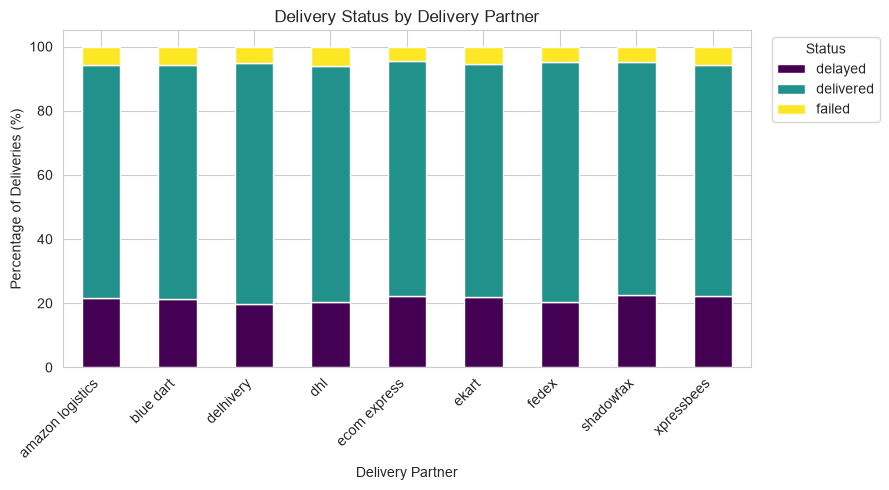

In [4]:
partner_status = pd.crosstab(df['delivery_partner'], df['delivery_status'], normalize='index').mul(100).round(2)
partner_status = partner_status.sort_values('failed', ascending=False)
print(partner_status)

partner_rating = df.groupby('delivery_partner')['delivery_rating'].mean().round(2).sort_values()
print("\nAverage rating by partner:")
print(partner_rating)

fig = plot_segment_status(df, 'delivery_partner')
fig.savefig(FIGURES_DIR / "03_delivery_status_by_partner.png", dpi=150)
plt.show()

**Finding:** Partner performance is also fairly narrow (failed rate
ranges ~4.4%-5.9%, delayed ~19.8%-22.4%). Delhivery has the best
delivered rate (75.2%) and lowest delay (19.8%); Xpressbees and Blue
Dart trend slightly worse. The spread is real but small — partners are
not the primary lever for fixing overall performance.

## 4. Vehicle Performance

Answers Business Question 4.

              avg_delivery_time  avg_cost  avg_rating
vehicle_type                                         
bike                       6.28    868.92        3.65
ev bike                    6.20    869.24        3.67
ev van                     6.25    866.18        3.68
scooter                    6.28    862.91        3.68
truck                      6.22    864.77        3.67
van                        6.27    857.66        3.66

 delivery_status  delayed  delivered  failed
vehicle_type                               
bike               21.51      72.96    5.53
ev bike            21.31      73.57    5.12
ev van             21.40      73.37    5.22
scooter            21.35      73.86    4.79
truck              21.23      72.96    5.81
van                21.38      73.23    5.40


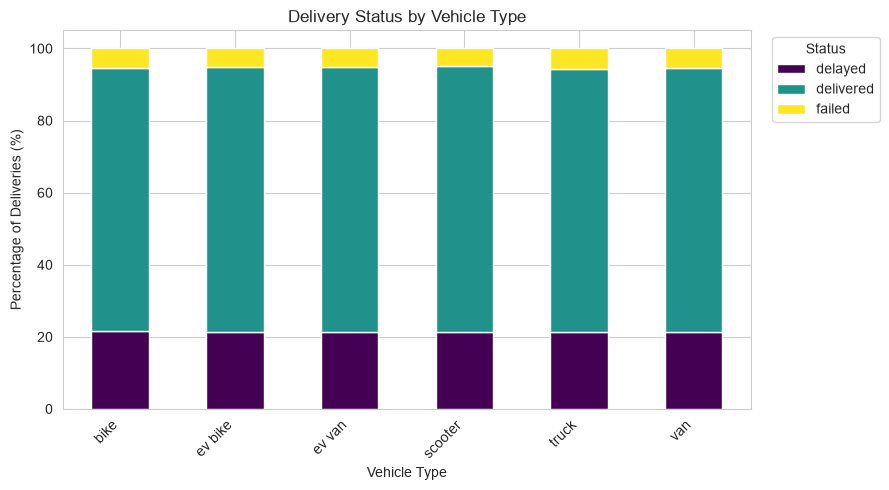

In [5]:
vehicle_summary = df.groupby('vehicle_type').agg(
    avg_delivery_time=('delivery_time_hours_clean', 'mean'),
    avg_cost=('delivery_cost', 'mean'),
    avg_rating=('delivery_rating', 'mean')
).round(2)
print(vehicle_summary)

vehicle_status = pd.crosstab(df['vehicle_type'], df['delivery_status'], normalize='index').mul(100).round(2)
print("\n", vehicle_status)

fig = plot_segment_status(df, 'vehicle_type')
fig.savefig(FIGURES_DIR / "04_delivery_status_by_vehicle.png", dpi=150)
plt.show()

**Finding:** Average delivery time (6.2-6.3 hrs) and cost (~₹858-869)
are nearly identical across all 6 vehicle types, and failure/delay rates
vary by less than 1 percentage point. Vehicle type does **not**
meaningfully drive performance or cost in this dataset — this is a
notable finding in itself (it suggests vehicle assignment is not
currently optimized around distance/cost, since we'd expect trucks vs
bikes to differ on longer routes).

## 5. Weather Impact

Answers Business Question 5.

delivery_status    delayed  delivered  failed
weather_condition                            
stormy               32.54      58.55    8.91
rainy                29.97      62.65    7.38
foggy                24.39      69.68    5.93
hot                  13.87      82.88    3.24
clear                14.26      82.57    3.18
cold                 12.87      83.98    3.15


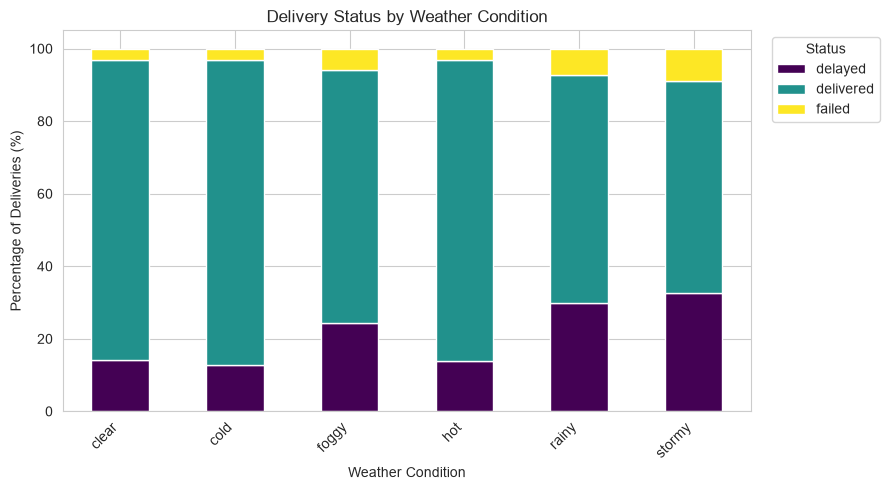

In [6]:
weather_status = pd.crosstab(df['weather_condition'], df['delivery_status'], normalize='index').mul(100).round(2)
weather_status = weather_status.sort_values('failed', ascending=False)
print(weather_status)

fig = plot_segment_status(df, 'weather_condition')
fig.savefig(FIGURES_DIR / "05_delivery_status_by_weather.png", dpi=150)
plt.show()

**Finding — this is the strongest signal in the dataset so far.**
Weather has a large, consistent effect on outcomes:

| Weather | Delayed % | Failed % |
|---|---|---|
| Clear | 14.3% | 3.2% |
| Cold | 12.9% | 3.2% |
| Hot | 13.9% | 3.2% |
| Foggy | 24.4% | 5.9% |
| Rainy | 30.0% | 7.4% |
| Stormy | 32.5% | 8.9% |

Stormy weather more than doubles the failure rate (8.9% vs 3.2% clear)
and more than doubles the delay rate (32.5% vs 14.3% clear). Rainy
weather shows a similarly severe pattern. This is the single clearest,
most actionable pattern found so far — unlike region, partner, or
vehicle, weather is a genuine, large-magnitude driver of delivery
failure.

## 6. Distance Analysis

Answers Business Question 6.

Correlation distance vs delivery time: 0.686
Correlation distance vs cost: 0.991


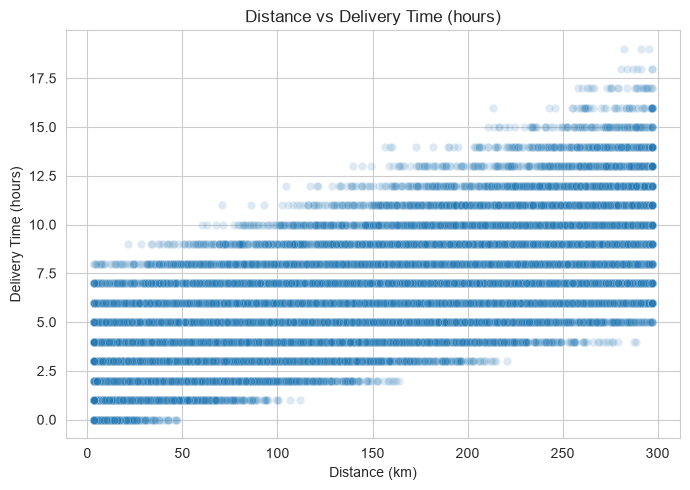

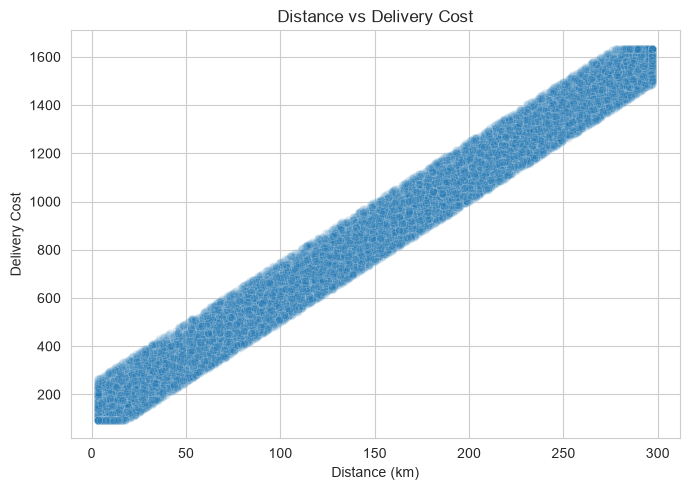

In [7]:
print("Correlation distance vs delivery time:", df['distance_km'].corr(df['delivery_time_hours_clean']).round(3))
print("Correlation distance vs cost:", df['distance_km'].corr(df['delivery_cost']).round(3))

fig1 = plot_distance_vs_metric(df, 'delivery_time_hours_clean', 'Delivery Time (hours)')
fig1.savefig(FIGURES_DIR / "06_distance_vs_time.png", dpi=150)
plt.show()

fig2 = plot_distance_vs_metric(df, 'delivery_cost', 'Delivery Cost')
fig2.savefig(FIGURES_DIR / "07_distance_vs_cost.png", dpi=150)
plt.show()

**Finding:** Distance correlates very strongly with cost (r ≈ 0.99) —
cost is essentially a direct function of distance, as expected. Distance
correlates moderately with delivery time (r ≈ 0.69) — longer distance
means longer delivery time, but the relationship isn't perfectly linear,
suggesting other factors (weather, handling) also affect duration.

## 7. Customer Satisfaction

Answers Business Question 7.

delivery_status
delayed      2.40
delivered    4.21
failed       1.31
Name: delivery_rating, dtype: float64

 delayed
no     4.21
yes    2.18
Name: delivery_rating, dtype: float64


e:\Python projects\last-mile-delivery-analysis\src\visualization\charts.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=status_col, y=rating_col, order=order, ax=ax, palette="viridis")


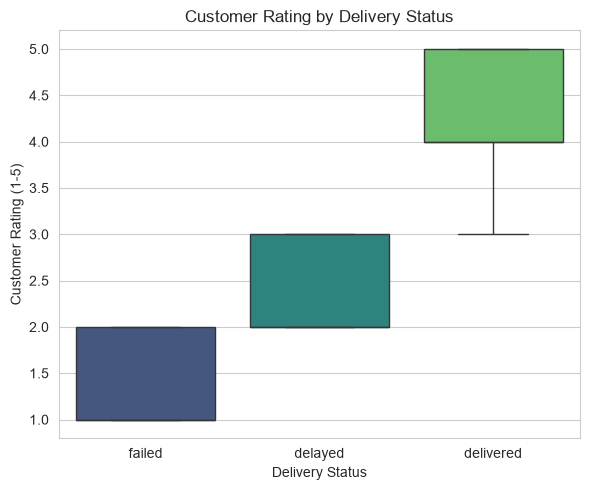

In [8]:
rating_by_status = df.groupby('delivery_status')['delivery_rating'].mean().round(2)
print(rating_by_status)

rating_by_delay = df.groupby('delayed')['delivery_rating'].mean().round(2)
print("\n", rating_by_delay)

fig = plot_rating_by_status(df)
fig.savefig(FIGURES_DIR / "08_rating_by_status.png", dpi=150)
plt.show()

**Finding:** Customer rating tracks delivery outcome very closely and
is the clearest downstream consequence of the problems found above:
`delivered` averages 4.21/5, `delayed` averages 2.40/5, and `failed`
averages just 1.31/5. Delay and failure directly and severely damage
customer satisfaction — this quantifies why fixing the weather-driven
delay/failure pattern (Section 5) matters commercially, not just
operationally.

## 8. Segment Analysis — Delivery Mode & Package Type

Per the Step 4 scope decision, calendar-based trend analysis is not
possible (no date/timestamp column). This section covers the comparable
"segment distribution" angle instead.

delivery_status  delayed  delivered  failed
delivery_mode                              
express            59.36      26.22   14.42
same day           25.78      67.46    6.75
standard            0.00     100.00    0.00
two day             0.35      99.57    0.08

Average cost by mode:
delivery_mode
express     880.43
same day    929.87
standard    819.34
two day     829.71
Name: delivery_cost, dtype: float64


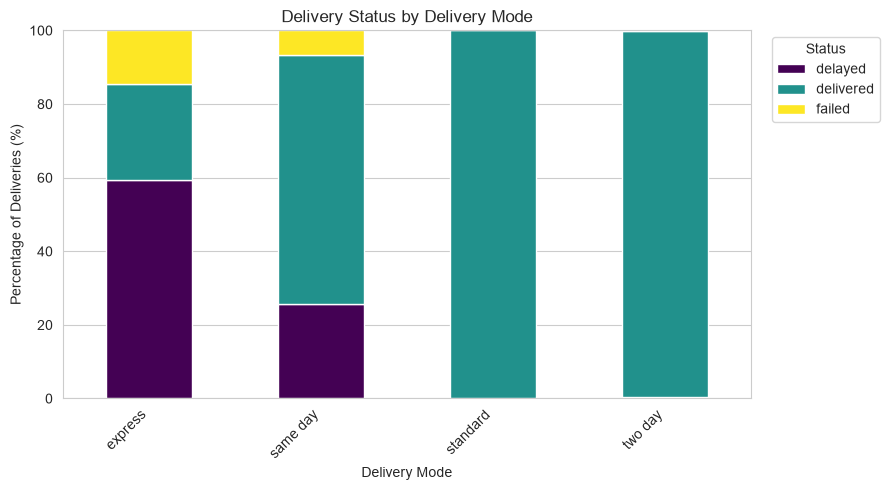

In [13]:
mode_status = pd.crosstab(df['delivery_mode'], df['delivery_status'], normalize='index').mul(100).round(2)
mode_cost = df.groupby('delivery_mode')['delivery_cost'].mean().round(2)
print(mode_status)
print("\nAverage cost by mode:")
print(mode_cost)

fig = plot_segment_status(df, 'delivery_mode')
fig.savefig(FIGURES_DIR / "09_delivery_status_by_mode.png", dpi=150)
plt.show()

**Finding — second major pattern in the dataset.** `delivery_mode`
shows dramatic, non-marginal differences unlike region/partner/vehicle:

| Mode | Delayed % | Failed % | Delivered % |
|---|---|---|---|
| Express | 59.4% | 14.4% | 26.2% |
| Same day | 25.8% | 6.8% | 67.5% |
| Two day | 0.3% | 0.1% | 99.6% |
| Standard | 0% | 0% | 100.0% |

Express delivery has by far the worst reliability — under 1 in 3 express
orders arrive on time, and its failure rate (14.4%) is nearly triple the
overall average. `standard` mode shows a perfect 100% delivered rate
with zero delays/failures across every record, which is unusually clean
— this pattern will be checked against the `delivery_mode` column
distribution in Business Analysis (Step 9) to confirm it's a genuine
operational segment and not a data artifact.

This is a stronger, more actionable finding than any regional or partner
difference: **the fastest delivery promise (express) is where the
company is least able to keep it.**

delivery_status   delayed  delivered  failed
package_type                                
automobile parts    20.43      73.81    5.76
clothing            20.60      73.91    5.49
cosmetics           21.65      72.96    5.39
documents           21.78      72.83    5.38
furniture           19.52      75.24    5.24
groceries           22.21      72.56    5.24
fragile items       21.42      73.35    5.23
pharmacy            22.49      72.46    5.05
electronics         22.17      72.82    5.01


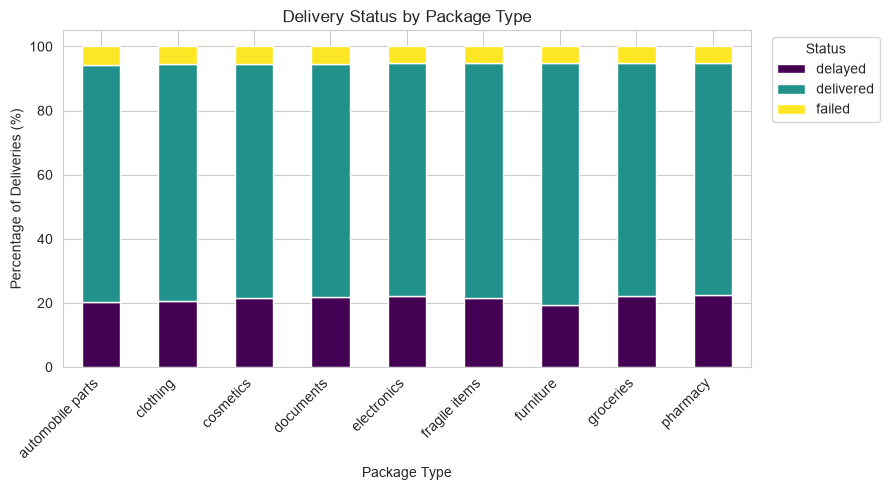

In [14]:
package_status = pd.crosstab(df['package_type'], df['delivery_status'], normalize='index').mul(100).round(2)
package_status = package_status.sort_values('failed', ascending=False)
print(package_status)

fig = plot_segment_status(df, 'package_type')
fig.savefig(FIGURES_DIR / "10_delivery_status_by_package_type.png", dpi=150)
plt.show()



**Finding:** Package type shows only small variation (failed rate
5.0%-5.8%), similar to region/partner/vehicle — not a major driver.

## 9. Does package type/weight affect delay or failure risk?

delivery_status    delayed  delivered  failed
package_weight_kg                            
26.82                 0.00       0.00   100.0
40.62                 0.00       0.00   100.0
10.65                 0.00       0.00   100.0
31.36                 0.00       0.00   100.0
33.46                 0.00       0.00   100.0
...                    ...        ...     ...
49.48                16.67      83.33     0.0
49.49                42.86      57.14     0.0
49.50                 0.00     100.00     0.0
49.51                 0.00     100.00     0.0
49.36                28.57      71.43     0.0

[4853 rows x 3 columns]


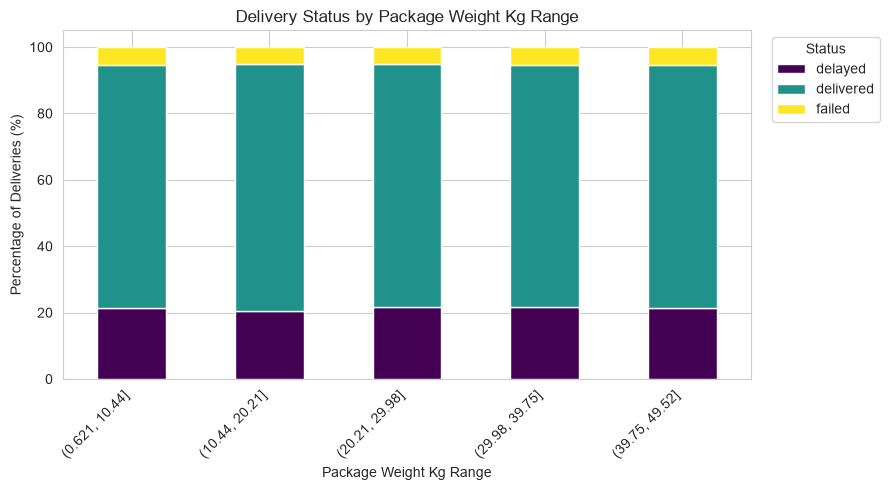

In [15]:
package_status = pd.crosstab(df['package_weight_kg'], df['delivery_status'], normalize='index').mul(100).round(2)
package_status = package_status.sort_values('failed', ascending=False)
print(package_status)

fig = plot_numeric_status(df, 'package_weight_kg')
fig.savefig(FIGURES_DIR / "11_delivery_status_by_package_weight_kg.png", dpi=150)
plt.show()

**Finding:** Package weight shows minimal variation in delivery performance (delayed ~21%–22%, delivered ~73%–74%, failed ~5%–6%) across weight ranges — not a major driver of delivery outcomes.

## 9. Correlation Overview

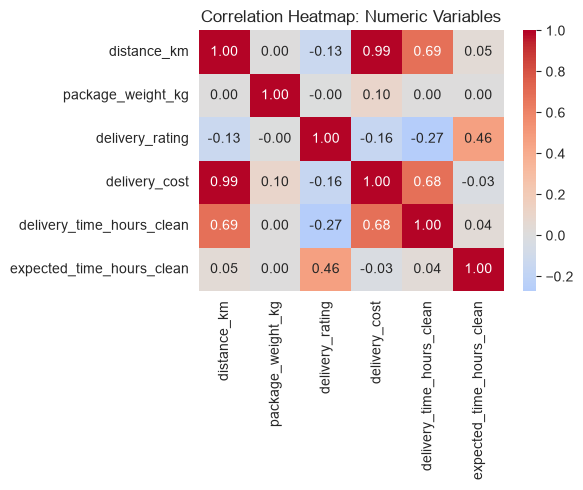

In [16]:
numeric_cols = ['distance_km', 'package_weight_kg', 'delivery_rating',
                'delivery_cost', 'delivery_time_hours_clean', 'expected_time_hours_clean']

fig = plot_correlation_heatmap(df, numeric_cols)
fig.savefig(FIGURES_DIR / "12_correlation_heatmap.png", dpi=150)
plt.show()

## EDA Summary

Ranked by strength of effect on delivery outcome:

1. **Weather** — strong, consistent driver. Stormy/rainy conditions
   roughly double delay and failure rates vs. clear weather.
2. **Delivery mode** — strong driver. Express is dramatically less
   reliable (59.4% delayed) than two day/standard (near 0%).
3. **Distance** — strongly drives cost (r≈0.99), moderately drives time
   (r≈0.69).
4. **Customer rating** — not a driver but the clearest consequence:
   directly tracks delivery outcome (4.21 delivered vs 1.31 failed).
5. **Region, delivery partner, vehicle type, package type** — all show
   only marginal (≤2 percentage point) variation. None of these are
   meaningful levers on their own.

This ranking directly sets the priorities for Business Analysis
: weather-related contingency planning and express-mode
reliability are the two highest-impact areas to investigate further,
not region or partner performance.